# Kernel Ridge Regression

## What it does
**Kernel Ridge Regression (KRR)** combines Ridge regularization with the **kernel trick**:
instead of explicitly mapping features to a high-dimensional space, it implicitly computes
inner products via the kernel function.

For the RBF (Gaussian) kernel:
$$k(x, x') = \exp\left(-\gamma \|x - x'\|^2\right)$$

The solution is:
$$\hat{y} = K(X_{\text{test}}, X_{\text{train}}) \,(K_{\text{train}} + \alpha I)^{-1} y_{\text{train}}$$

where $K_{\text{train}}$ is the $n \times n$ kernel matrix of the training set.

## KRR vs RBF Regression
| | KernelRidge | RBF (RBFSampler + Ridge) |
|---|---|---|
| Kernel approximation | Exact | Random Fourier features (approximate) |
| Complexity | O(n² memory, n³ fit) | O(nm) fit — scales to large datasets |
| Best for | Small–medium samples (<10k obs) | Large samples |

## When to use it
- You have a small-to-medium dataset and want the exact RBF kernel without approximation
- You want a smooth, non-linear regression with a single interpretable bandwidth parameter
- Use as a strong non-linear baseline; compare with GBR and RBF regression

## Data format
Panel CSV/Parquet with `DATE_COL`, `ID_COL`, `TARGET_COL`; all other numeric columns are features.
**Note:** if the training set is very large (>50k obs), consider using `rbf_regression.ipynb`
instead, which uses RBFSampler and scales linearly.

## Configuration

In [1]:
CONFIG = {
    # --- Data ---
    'DATA_FILE':          '../../data/largeml.pq',
    'DATE_COL':           'yyyymm',
    'ID_COL':             'permno',
    'TARGET_COL':         'ret',
    # --- Time splits (year-based) ---
    'TRAIN_YEARS':        20,
    'VAL_YEARS':          12,
    # --- Preprocessing ---
    'MISSING_FILL_VALUE': 0,
    'STANDARDIZE':        True,
    # --- KernelRidge grid ---
    'ALPHAS':             [0.01, 0.1, 1.0, 10.0, 100.0],   # Ridge regularization
    'GAMMAS':             [0.001, 0.01, 0.1, 1.0, 10.0],   # RBF bandwidth
    'KERNEL':             'rbf',
    # --- Subsampling (KRR is O(n²) — subsample if training set is too large) ---
    'MAX_TRAIN_OBS':      10000,   # set to None to disable subsampling
    'SUBSAMPLE_SEED':     42,
    # --- Portfolio ---
    'N_DECILES':          10,
    # --- Output ---
    'SAVE_RESULTS':       True,
    'OUTPUT_DIR':         '../../results',
}

print('Configuration loaded.')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')

Configuration loaded.
  DATA_FILE: ../../data/largeml.pq
  DATE_COL: yyyymm
  ID_COL: permno
  TARGET_COL: ret
  TRAIN_YEARS: 20
  VAL_YEARS: 12
  MISSING_FILL_VALUE: 0
  STANDARDIZE: True
  ALPHAS: [0.01, 0.1, 1.0, 10.0, 100.0]
  GAMMAS: [0.001, 0.01, 0.1, 1.0, 10.0]
  KERNEL: rbf
  MAX_TRAIN_OBS: 10000
  SUBSAMPLE_SEED: 42
  N_DECILES: 10
  SAVE_RESULTS: True
  OUTPUT_DIR: results


## Step 1 — Load Data & Define Time Splits

In [2]:
import sys, warnings, os, itertools
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.kernel_ridge import KernelRidge

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('../../').resolve()))
from utils import (
    load_parquet, time_series_split, prepare_panel_data,
    standardize_splits, drop_na_targets,
    compute_oos_r2, evaluate_splits,
    form_long_short_portfolio, portfolio_summary,
    build_run_summary, save_run_summary, save_portfolio_compositions,
)

df = load_parquet(CONFIG['DATA_FILE'])
df[CONFIG['DATE_COL']] = pd.to_numeric(df[CONFIG['DATE_COL']])
print(f'Dataset shape : {df.shape}')
print(f'Date range    : {df[CONFIG["DATE_COL"]].min()} — {df[CONFIG["DATE_COL"]].max()}')
df.head()

Dataset shape : (79146, 212)
Date range    : 192512 — 202211


,permno,yyyymm,AM,AOP,AbnormalAccruals,Accruals,AccrualsBM,Activism1,Activism2,AdExp,...,roaq,sfe,sinAlgo,skew1,std_turn,tang,zerotrade12M,zerotrade1M,zerotrade6M,ret
0,10078,198606,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.393044e-08,NaN,-0.118056
1,10078,198607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.737205e-08,NaN,-0.039370
2,10078,198609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.597698e-08,1.857281e-07,-0.008850
3,10078,198610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.763825e-08,2.111030e-07,0.348214
4,10078,198612,0.236302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.718727,NaN,5.878542e-09,8.619326e-08,0.109827


In [3]:
train_mask, val_mask, test_mask, split_info = time_series_split(
    df, date_col=CONFIG['DATE_COL'],
    train_years=CONFIG['TRAIN_YEARS'], val_years=CONFIG['VAL_YEARS'],
)
print(f"Training   : {split_info['train_start']} — {split_info['train_end']}  ({split_info['train_n_obs']:,} obs)")
print(f"Validation : {split_info['val_start']}   — {split_info['val_end']}    ({split_info['val_n_obs']:,} obs)")
print(f"Test       : {split_info['test_start']}   — {split_info['test_end']}    ({split_info['test_n_obs']:,} obs)")

Training   : 1925 — 1944  (889 obs)
Validation : 1945   — 1956    (709 obs)
Test       : 1957   — 2022    (77,548 obs)


## Step 2 — Prepare Features & Standardize

In [4]:
X, y, feature_cols = prepare_panel_data(
    df, target_col=CONFIG['TARGET_COL'],
    exclude_cols=[CONFIG['DATE_COL'], CONFIG['ID_COL']],
    fill_value=CONFIG['MISSING_FILL_VALUE'],
)

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

(X_train, y_train), (X_val, y_val), (X_test, y_test) = drop_na_targets(
    (X_train, y_train), (X_val, y_val), (X_test, y_test)
)

if CONFIG['STANDARDIZE']:
    X_train, X_val, X_test, scaler = standardize_splits(X_train, X_val, X_test)
    print('Features standardized (fit on training data only).')

# Optional subsampling: KRR builds an n×n kernel matrix
if CONFIG['MAX_TRAIN_OBS'] and len(y_train) > CONFIG['MAX_TRAIN_OBS']:
    rng  = np.random.default_rng(CONFIG['SUBSAMPLE_SEED'])
    idx  = rng.choice(len(y_train), size=CONFIG['MAX_TRAIN_OBS'], replace=False)
    X_train_fit = X_train.iloc[idx] if hasattr(X_train, 'iloc') else X_train[idx]
    y_train_fit = y_train.iloc[idx] if hasattr(y_train, 'iloc') else y_train[idx]
    print(f'Subsampled training set to {CONFIG["MAX_TRAIN_OBS"]:,} obs for KRR.')
else:
    X_train_fit, y_train_fit = X_train, y_train

y_train_mean = float(y_train.mean())
print(f'Features      : {len(feature_cols)}')
print(f'KRR fit obs   : {X_train_fit.shape[0]:,}')
print(f'Training mean : {y_train_mean:.6f}')

Features standardized (fit on training data only).
Features      : 209
KRR fit obs   : 884
Training mean : 0.007120


## Step 3 — 2D Grid Search: alpha × gamma

Best hyperparameters selected by **validation OOS R²** — test set never touched.

In [5]:
grid_results = []

for alpha in CONFIG['ALPHAS']:
    for gamma in CONFIG['GAMMAS']:
        kr = KernelRidge(alpha=alpha, kernel=CONFIG['KERNEL'], gamma=gamma)
        kr.fit(X_train_fit, y_train_fit)
        val_pred = kr.predict(X_val)
        oos_r2   = compute_oos_r2(y_val.values, val_pred, y_train_mean)
        grid_results.append({'alpha': alpha, 'gamma': gamma,
                              'oos_r2_val': oos_r2, 'model': kr})
        print(f'  alpha={alpha:.4f}  gamma={gamma:.4f}  Val OOS R²={oos_r2*100:+.4f}%')

best = max(grid_results, key=lambda r: r['oos_r2_val'])
print(f"\nBest: alpha={best['alpha']}, gamma={best['gamma']}  "
      f"(Val OOS R² = {best['oos_r2_val']*100:+.4f}%)")

  alpha=0.0100  gamma=0.0010  Val OOS R²=-71.3035%


  alpha=0.0100  gamma=0.0100  Val OOS R²=-47.3209%


  alpha=0.0100  gamma=0.1000  Val OOS R²=-1.8443%
  alpha=0.0100  gamma=1.0000  Val OOS R²=-4.7677%
  alpha=0.0100  gamma=10.0000  Val OOS R²=-4.7672%
  alpha=0.1000  gamma=0.0010  Val OOS R²=-13.6363%
  alpha=0.1000  gamma=0.0100  Val OOS R²=-23.8850%
  alpha=0.1000  gamma=0.1000  Val OOS R²=-2.0337%


  alpha=0.1000  gamma=1.0000  Val OOS R²=-4.7679%


  alpha=0.1000  gamma=10.0000  Val OOS R²=-4.7672%


  alpha=1.0000  gamma=0.0010  Val OOS R²=+14.6380%
  alpha=1.0000  gamma=0.0100  Val OOS R²=+5.6952%
  alpha=1.0000  gamma=0.1000  Val OOS R²=-2.7940%
  alpha=1.0000  gamma=1.0000  Val OOS R²=-4.7683%
  alpha=1.0000  gamma=10.0000  Val OOS R²=-4.7672%
  alpha=10.0000  gamma=0.0010  Val OOS R²=+7.1474%


  alpha=10.0000  gamma=0.0100  Val OOS R²=+5.9413%


  alpha=10.0000  gamma=0.1000  Val OOS R²=-4.0905%


  alpha=10.0000  gamma=1.0000  Val OOS R²=-4.7675%
  alpha=10.0000  gamma=10.0000  Val OOS R²=-4.7672%
  alpha=100.0000  gamma=0.0010  Val OOS R²=+0.1034%
  alpha=100.0000  gamma=0.0100  Val OOS R²=-0.9696%
  alpha=100.0000  gamma=0.1000  Val OOS R²=-4.6693%
  alpha=100.0000  gamma=1.0000  Val OOS R²=-4.7672%
  alpha=100.0000  gamma=10.0000  Val OOS R²=-4.7672%

Best: alpha=1.0, gamma=0.001  (Val OOS R² = +14.6380%)


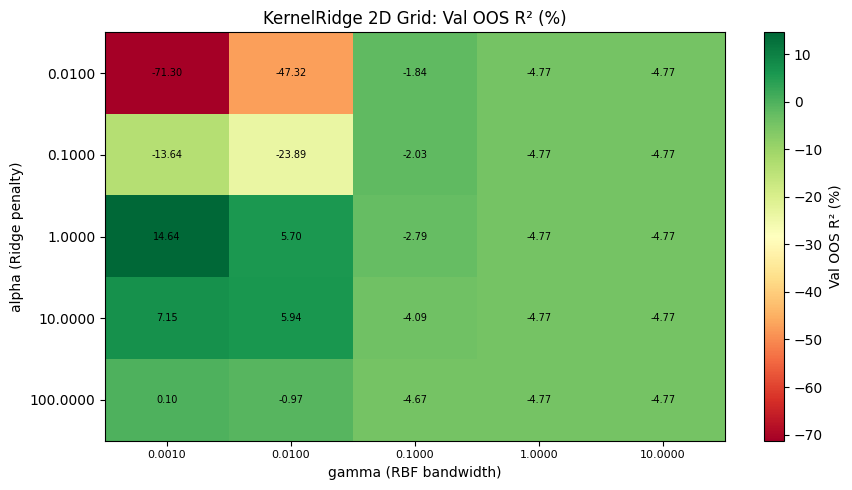

In [6]:
grid_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'model'} for r in grid_results])
pivot   = grid_df.pivot(index='alpha', columns='gamma', values='oos_r2_val') * 100

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{v:.4f}' for v in pivot.columns], fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'{v:.4f}' for v in pivot.index])
ax.set_xlabel('gamma (RBF bandwidth)')
ax.set_ylabel('alpha (Ridge penalty)')
ax.set_title('KernelRidge 2D Grid: Val OOS R² (%)')
for i, j in itertools.product(range(len(pivot.index)), range(len(pivot.columns))):
    ax.text(j, i, f'{pivot.values[i, j]:.2f}', ha='center', va='center', fontsize=7)
plt.colorbar(im, ax=ax, label='Val OOS R² (%)')
plt.tight_layout()
plt.show()

## Step 4 — Final Evaluation on All Splits

In [7]:
best_model = best['model']

preds = {
    'train': best_model.predict(X_train),
    'val':   best_model.predict(X_val),
    'test':  best_model.predict(X_test),
}

metrics = evaluate_splits(
    y_train, preds['train'], y_val, preds['val'], y_test, preds['test'],
    train_mean=y_train_mean,
)

print('KERNEL RIDGE — BEST MODEL EVALUATION')
print('=' * 55)
print(f"  Alpha          : {best['alpha']}")
print(f"  Gamma          : {best['gamma']}")
print(f"  Kernel         : {CONFIG['KERNEL']}")
print()
print(f"  Train R²       : {metrics['r2_train']*100:+.4f}%")
print(f"  Val R²         : {metrics['r2_val']*100:+.4f}%")
print(f"  Test R²        : {metrics['r2_test']*100:+.4f}%")
print()
print(f"  OOS R² Val     : {metrics['oos_r2_val']*100:+.4f}%")
print(f"  OOS R² Test    : {metrics['oos_r2_test']*100:+.4f}%")
print('=' * 55)

KERNEL RIDGE — BEST MODEL EVALUATION
  Alpha          : 1.0
  Gamma          : 0.001
  Kernel         : rbf

  Train R²       : +24.3715%
  Val R²         : +13.1135%
  Test R²        : -1.1875%

  OOS R² Val     : +14.6380%
  OOS R² Test    : -0.6232%


## Step 5 — Portfolio Formation & Sharpe Ratio

KERNEL RIDGE LONG-SHORT PORTFOLIO
  Months         : 552
  Mean monthly   : 1.3936%
  Std monthly    : 5.3116%
  Sharpe (ann.)  : 0.9089


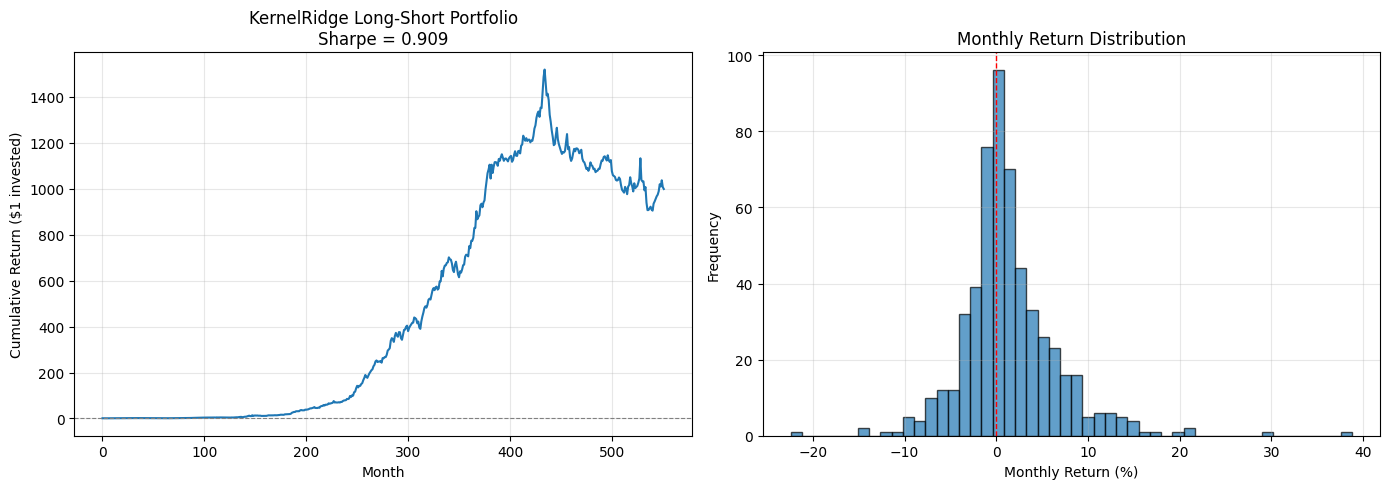

In [8]:
test_df_base = df.loc[y_test.index, [CONFIG['DATE_COL'], CONFIG['ID_COL'], CONFIG['TARGET_COL']]].copy()
test_df_base['predicted_ret'] = preds['test']
test_df_base = test_df_base.rename(columns={CONFIG['TARGET_COL']: 'actual_ret'})

port_returns, comp_df = form_long_short_portfolio(
    test_df_base, date_col=CONFIG['DATE_COL'],
    pred_col='predicted_ret', ret_col='actual_ret',
    n_deciles=CONFIG['N_DECILES'],
)
port_stats = portfolio_summary(port_returns)

print('KERNEL RIDGE LONG-SHORT PORTFOLIO')
print('=' * 50)
print(f"  Months         : {port_stats['n_periods']}")
print(f"  Mean monthly   : {port_stats['mean_period_return']*100:.4f}%")
print(f"  Std monthly    : {port_stats['std_period_return']*100:.4f}%")
print(f"  Sharpe (ann.)  : {port_stats['sharpe_annualized']:.4f}")
print('=' * 50)

cumulative = (1 + port_returns).cumprod()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(range(len(cumulative)), cumulative.values, linewidth=1.5)
axes[0].axhline(y=1, color='gray', linestyle='--', linewidth=0.8)
axes[0].set(xlabel='Month', ylabel='Cumulative Return ($1 invested)',
            title=f'KernelRidge Long-Short Portfolio\nSharpe = {port_stats["sharpe_annualized"]:.3f}')
axes[0].grid(True, alpha=0.3)
axes[1].hist(port_returns.values * 100, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].set(xlabel='Monthly Return (%)', ylabel='Frequency', title='Monthly Return Distribution')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6 — Save Results

In [9]:
if CONFIG['SAVE_RESULTS']:
    summary = build_run_summary(
        model_name    = 'Kernel Ridge',
        description   = f'KernelRidge(kernel={CONFIG["KERNEL"]}) — exact RBF kernel regression',
        tuning_params = f"alpha={best['alpha']}, gamma={best['gamma']}, kernel={CONFIG['KERNEL']}",
        metrics       = metrics,
        portfolio_stats = port_stats,
        split_info    = split_info,
        n_features    = len(feature_cols),
        fill_value    = CONFIG['MISSING_FILL_VALUE'],
        standardized  = CONFIG['STANDARDIZE'],
        notebook      = 'kernel_ridge',
    )
    path = save_run_summary(summary, CONFIG['OUTPUT_DIR'], 'kernel_ridge_summary.csv')
    print(f'Saved: {path}')
    path = save_portfolio_compositions(comp_df, CONFIG['OUTPUT_DIR'], 'kernel_ridge_portfolios.csv')
    print(f'Saved: {path}')
else:
    print('SAVE_RESULTS = False — skipping.')

Saved: results/kernel_ridge_summary.csv
Saved: results/kernel_ridge_portfolios.csv
